In [16]:
import importlib
import cleaning
importlib.reload(cleaning)
from cleaning import load_raw, build_clean_layer

# Пересобрать с нуля
raw = load_raw('../data/raw/wec_laps.parquet')
clean = build_clean_layer(raw)

print(f"Raw rows:   {len(raw):,}")
print(f"Clean rows: {len(clean):,}")

Raw rows:   334,980
Clean rows: 334,980


In [17]:
import sys
sys.path.append('../src')

import pandas as pd
from cleaning import load_raw, build_clean_layer

raw = load_raw('../data/raw/wec_laps.parquet')
clean = build_clean_layer(raw)

print(f"Raw rows:   {len(raw):,}")
print(f"Clean rows: {len(clean):,}")
print(f"New columns: {[c for c in clean.columns if c not in raw.columns]}")

Raw rows:   334,980
Clean rows: 334,980
New columns: ['homologation_group', 'car_model_key', 'is_pit_lap', 'is_stint_start_lap', 'is_stint_end_lap', 'is_flagged_lap', 'is_wet_lap', 'weather_bucket', 'is_outlier_lap', 'exclusion_reason', 'valid_for_pace_analysis', 'valid_for_stint_analysis', 'track_temp_bucket', 'tire_age_bucket']


In [18]:
print("=== exclusion_reason distribution ===")
print(clean['exclusion_reason'].value_counts(dropna=False))

print("\n=== valid_for_pace_analysis ===")
print(clean['valid_for_pace_analysis'].value_counts())

print("\n=== valid_for_stint_analysis ===")
print(clean['valid_for_stint_analysis'].value_counts())

=== exclusion_reason distribution ===
exclusion_reason
None               239875
pit_lap             33700
outlier_lap         31342
stint_end_lap       17032
flagged_lap         12303
stint_start_lap       728
Name: count, dtype: int64

=== valid_for_pace_analysis ===
valid_for_pace_analysis
False    237039
True      97941
Name: count, dtype: int64

=== valid_for_stint_analysis ===
valid_for_stint_analysis
False    223813
True     111167
Name: count, dtype: int64


In [19]:
pace_df = clean[clean['valid_for_pace_analysis']]

print("=== Pace-valid laps by class ===")
print(pace_df['class_normalized'].value_counts())

print("\n=== Pace-valid laps by homologation_group ===")
print(pace_df['homologation_group'].value_counts())

print("\n=== car_model_key examples ===")
print(pace_df['car_model_key'].unique())

=== Pace-valid laps by class ===
class_normalized
HYPERCAR    61342
GT3         36599
Name: count, dtype: int64

=== Pace-valid laps by homologation_group ===
homologation_group
LMH     39103
GT3     36599
LMDh    22239
Name: count, dtype: int64

=== car_model_key examples ===
<ArrowStringArray>
[          'Toyota_LMH',           'Alpine_LMH',      'Glickenhaus_LMH',
          'Peugeot_LMH',        'Cadillac_LMDh',          'Vanwall_LMH',
         'Porsche_LMDh',          'Ferrari_LMH',             'BMW_LMDh',
     'Aston Martin_GT3',              'BMW_GT3',          'Ferrari_GT3',
          'McLaren_GT3',      'Lamborghini_GT3',     'Lamborghini_LMDh',
             'Ford_GT3',            'Lexus_GT3',        'Chevrolet_GT3',
          'Porsche_GT3', 'Isotta Fraschini_LMH',     'Aston Martin_LMH',
     'Mercedes-AMG_GT3']
Length: 22, dtype: str


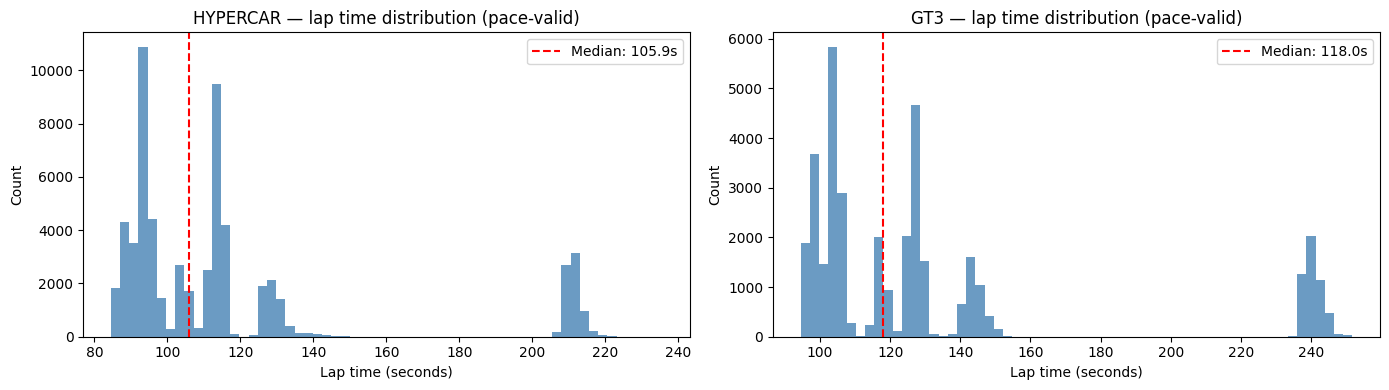

In [20]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, cls in zip(axes, ['HYPERCAR', 'GT3']):
    subset = pace_df[pace_df['class_normalized'] == cls]['lap_time']
    ax.hist(subset, bins=60, color='steelblue', edgecolor='none', alpha=0.8)
    ax.set_title(f'{cls} — lap time distribution (pace-valid)')
    ax.set_xlabel('Lap time (seconds)')
    ax.set_ylabel('Count')
    ax.axvline(subset.median(), color='red', linestyle='--', label=f'Median: {subset.median():.1f}s')
    ax.legend()

plt.tight_layout()
plt.savefig('../reports/lap_time_distribution.png', dpi=150)
plt.show()

stint_start_lap = 205
stint_end_lap = 11452

In [21]:
print("=== stint_start field distribution ===")
print(clean['stint_start'].value_counts(dropna=False))

print("\n=== is_stint_start_lap vs is_stint_end_lap ===")
print(f"start laps: {clean['is_stint_start_lap'].sum():,}")
print(f"end laps:   {clean['is_stint_end_lap'].sum():,}")

# Проверим сколько уникальных стинтов должно быть
stints = clean[clean['session'].isin(['race'])].groupby(
    ['session_id', 'car', 'stint_number']
).size()
print(f"\nUnique stints in race: {len(stints):,}")
print(f"Expected start laps ≈ {len(stints):,}")

=== stint_start field distribution ===
stint_start
False    315562
True      19418
Name: count, dtype: int64

=== is_stint_start_lap vs is_stint_end_lap ===
start laps: 19,418
end laps:   19,277

Unique stints in race: 3,984
Expected start laps ≈ 3,984


In [22]:
print("=== outlier_lap per session ===")
print(clean.groupby('session')['is_outlier_lap'].agg(['sum', 'mean']).round(3))

print("\n=== outlier_lap per class_normalized ===")
print(clean.groupby('class_normalized')['is_outlier_lap'].agg(['sum', 'mean']).round(3))

=== outlier_lap per session ===
              sum   mean
session                 
practice    12588  0.104
qualifying   1287  0.136
race        14530  0.083
test         2737  0.097
warmup        200  0.260

=== outlier_lap per class_normalized ===
                    sum   mean
class_normalized              
GT3                8052  0.089
HYPERCAR          14355  0.098
LMP2               8935  0.091


In [ ]:
import sqlite3
import sys
sys.path.append('../src')
from data_io import save_to_sqlite  # ← было 'io'

DB_PATH = '../data/processed/wec_bop.db'

CLEAN_COLUMNS = [
    'year', 'start_date', 'event', 'session', 'session_id',
    'car', 'class_normalized', 'homologation_group', 'car_model_key',
    'manufacturer', 'chassis', 'homologation',
    'driver_name', 'driver_id', 'team_name', 'license', 'license_rank',
    'lap', 'lap_time', 'lap_time_s1', 'lap_time_s2', 'lap_time_s3',
    'stint_number', 'stint_lap', 'est_tire_age',
    'flags', 'pit_time',
    'is_pit_lap', 'is_stint_start_lap', 'is_stint_end_lap',
    'is_flagged_lap', 'is_wet_lap', 'is_outlier_lap',
    'valid_for_pace_analysis', 'valid_for_stint_analysis',
    'exclusion_reason', 'weather_bucket', 'track_temp_bucket', 'tire_age_bucket',
    'air_temp_f', 'track_temp_f', 'humidity_percent', 'raining'
]

clean_to_save = clean[CLEAN_COLUMNS].copy()

conn = sqlite3.connect(DB_PATH)
clean_to_save.to_sql('clean_wec_laps', conn, if_exists='replace', index=False)
conn.close()

print(f"Saved {len(clean_to_save):,} rows to clean_wec_laps")
print(f"DB: {DB_PATH}")

ImportError: cannot import name 'save_to_sqlite' from 'io' (C:\Users\Matvey\AppData\Local\Programs\Python\Python312\Lib\io.py)